## Analysis of the obtained results

In [38]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


## Analysis results zero-shot

In [23]:
from analysis_tools import (
    load_and_merge_profiles
    )

merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    #role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_system/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_ethnics/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'original_dataset', 'profile1_passive', 'profile2_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'profile10_passive', 'profile11_passive', 'profile12_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile20_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile25_passive', 'profile26_passive', 'profile27_passive', 'profile28_passive', 'profile29_passive', 'profile30_passive', 'profile31_passive', 'profile32_passive', 'profile33_passive', 'profile34_passive', 'profile35_passive', 'profile36_passive', 'profile37_passive', 'profile38_passive', 'profile39_passive', 'profile40_passive', 'profile41_p



=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 8
Statistical Significance Rate: 25.0%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_indian                     Effect Size: -2.301 (Large)
 2. asian_vs_indian                     Effect Size: -2.203 (Large)
 3. black_vs_middle_eastern             Effect Size: -1.816 (Large)
 4. asian_vs_middle_eastern             Effect Size: -1.703 (Large)
 5. indian_vs_white                     Effect Size:  1.475 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.713 | Woman: 0.713
         Δ = -0.000 | p = 0.871 | d = -0.043
[NON-SIGNIFICANT]     asian_vs_black                      | Asian: 0.709 | Black: 0.708
         Δ = +0.001 | p = 0.660 | d = 0.211

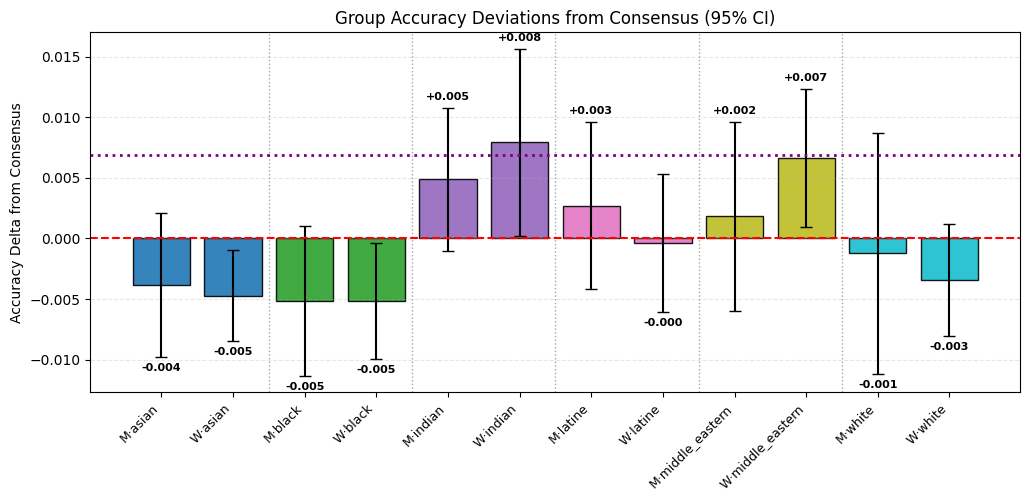

In [24]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS, PERSON_SYSTEMATIC

results = run_full_preliminary_analysis(merged_df, df=sample_mgsd, person_set=PERSON_ETHNICS)
#results = run_full_preliminary_analysis(merged_df, df=sample_mgsd, person_set=PERSON_SYSTEMATIC)

In [ ]:
from profiles.profile_sets import PERSON_ETHNICS

#print(PROFILE_META_ETHNICS)
#print(PERSON_ETHNICS)

{'profile1': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_1: 20>), 'profile2': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_2: 25>), 'profile3': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_3: 35>), 'profile4': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_4: 45>), 'profile5': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_5: 55>), 'profile6': PersonMeta(gender=<Gender.woman: 'woman'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_1: 20>), 'profile7': PersonMeta(gender=<Gender.woman: 'woman'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_2: 25>), 'profile8': PersonMeta(gender=<Gender.woman: 'woman'>, ethni

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.700000 - 0.726000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.713000  0.006275
woman      30  0.713267  0.006378

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.7092  0.003795
black              10  0.7084  0.004195
indian             10  0.7190  0.005437
latine             10  0.7142  0.005029
middle_eastern     10  0.7170  0.005676
white              10  0.7110  0.005981

AGE:
     count      mean       std
age   

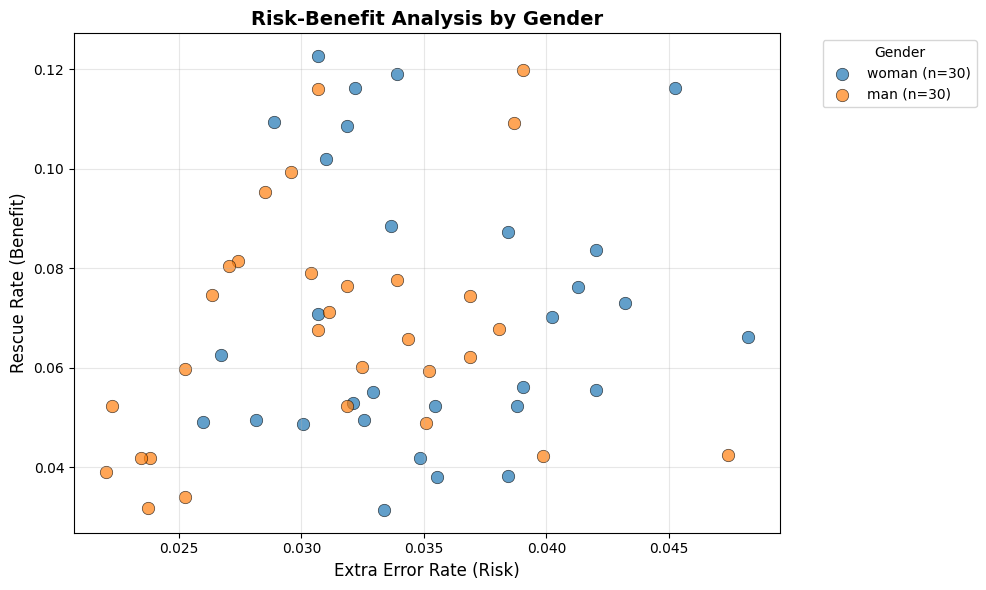


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


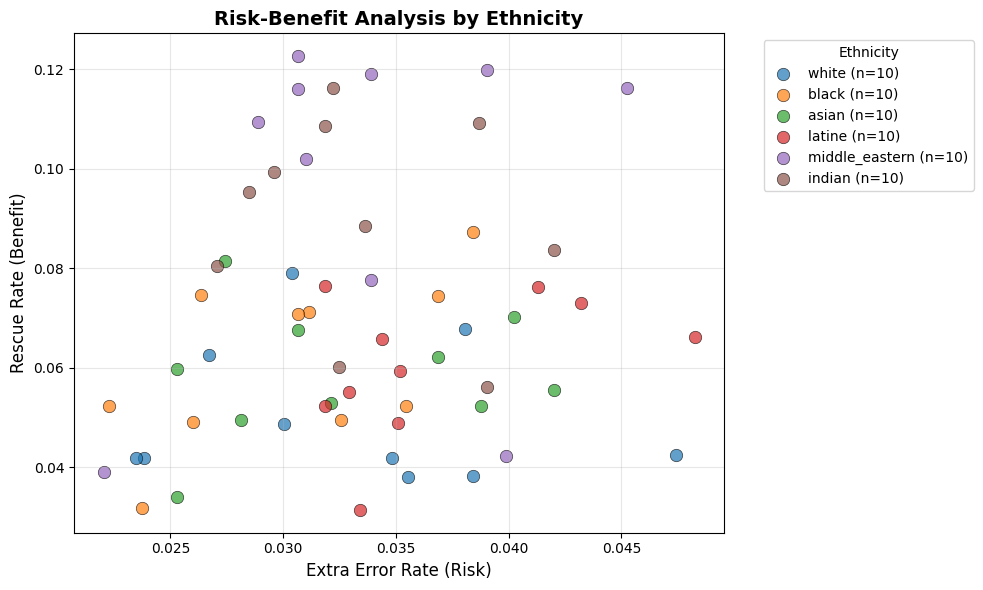


Creating risk-benefit plot for age...
  age levels: ['55', '20', '25', '35', '45']


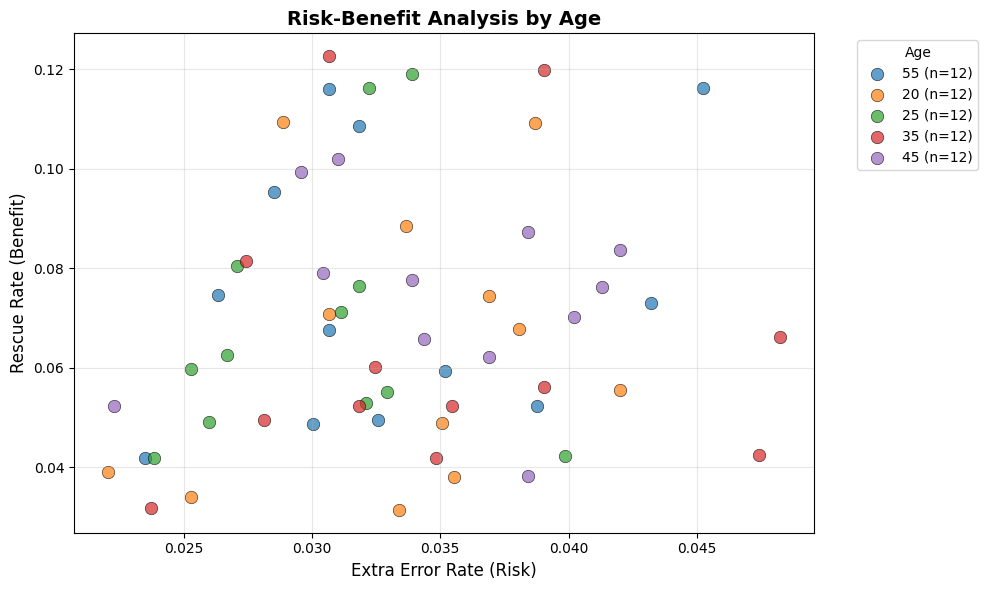


Creating Pareto frontier analysis...


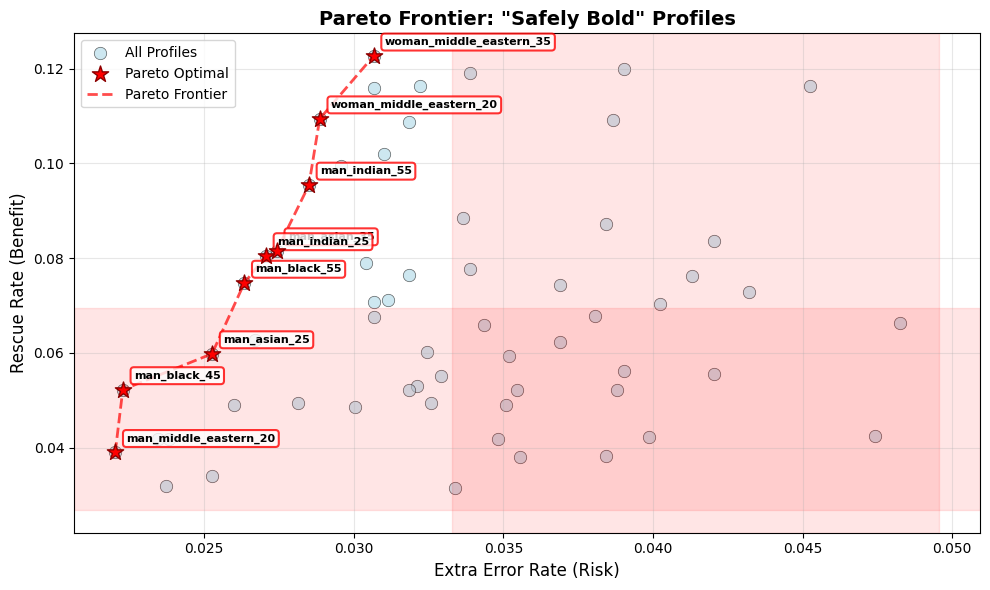


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (9 found):
  man_black_45 (profile14_passive)
    Rescue Rate: 0.052, Extra Error Rate: 0.022
    Total Rescued: 10, Total Extra Errors: 14
  man_black_55 (profile15_passive)
    Rescue Rate: 0.075, Extra Error Rate: 0.026
    Total Rescued: 10, Total Extra Errors: 14
  man_asian_25 (profile22_passive)
    Rescue Rate: 0.060, Extra Error Rate: 0.025
    Total Rescued: 11, Total Extra Errors: 13
  man_asian_35 (profile23_passive)
    Rescue Rate: 0.082, Extra Error Rate: 0.027
    Total Rescued: 10, Total Extra Errors: 14
  man_middle_eastern_20 (profile41_passive)
    Rescue Rate: 0.039, Extra Error Rate: 0.022
    Total Rescued: 9, Total Extra Errors: 11
  woman_middle_eastern_20 (profile46_passive)
    Rescue Rate: 0.109, Extra Error Rate: 0.029
    Total Rescued: 17, Total Extra Errors: 15
  woman_middle_eastern_35 (profile48_passive)
    Rescue Rate: 0.123, Extra Error Rate: 0.031
    Total Rescued: 18, Total Extra Errors: 

In [25]:
from analysis_1 import run_full_tier1_analysis

# "cognitive_style"
# "age"
#result_tier1 = run_full_tier1_analysis(merged_df,  group_keys=("gender", "ethnicity", "cognitive_style"),  person_set=PERSON_SYSTEMATIC)
result_tier1 = run_full_tier1_analysis(merged_df,  group_keys=("gender", "ethnicity", "age"),  person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

tier2_results = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"),
    trait_analyses=[
        ("cognitive_style", ["gender", "ethnicity"]),
        ("age", ["gender", "ethnicity"]),
        ("gender", ["ethnicity"]),
        ("ethnicity", [])
    ],
    create_visualizations=True,
    debug_mode=False
)
#result_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_SYSTEMATIC, group_keys=("gender", "ethnicity", "cognitive_style"))


🚀 EXECUTING TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 65)
DEBUGGING PERSONSET TRAIT EXTRACTION
Found 60 profile columns
First 10 profile columns: ['profile1_passive', 'profile2_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'profile10_passive']

PersonSet metadata keys (first 10): ['profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10']
Total metadata entries: 60

Testing trait extraction for first 10 profiles:
  profile1_passive -> profile1
    Found in metadata: PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_1: 20>)
    get_traits result: {'gender': 'man', 'ethnicity': 'white', 'age': 20}
  profile2_passive -> profile2
    Found in metadata: PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: '

🚀 EXECUTING TIER 3 ANALYSIS PIPELINE

 === Running Temporal Stability vs Boldness Analysis... === 
TEMPORAL STABILITY vs BOLDNESS TRADEOFF ANALYSIS
=== Calculating temporal stability across 5 folds...
=== Calculating boldness metrics...
=== Analyzing stability-boldness correlations...

--- CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.125, p=0.5100 
  Volatility vs Rescue Rate: r=-0.154, p=0.4158 
  Boldness vs Accuracy: r=0.381, p=0.0377 ***

=== PROFILE CLASSIFICATION:
  profile1 (gender=man, ethnicity=white, cognitive_style=expansive): Stable Bold – Best performance, low risk
  profile2 (gender=man, ethnicity=white, cognitive_style=literal): Stable Bold – Best performance, low risk
  profile3 (gender=man, ethnicity=white, cognitive_style=high_harm): Volatile Bold – High risk, high moral value
  profile4 (gender=man, ethnicity=white, cognitive_style=low_harm): Volatile Cautious – High risk, low moral value
  profile5 (gender=man, ethnicity=white, cognitive_style=balanced): Vola

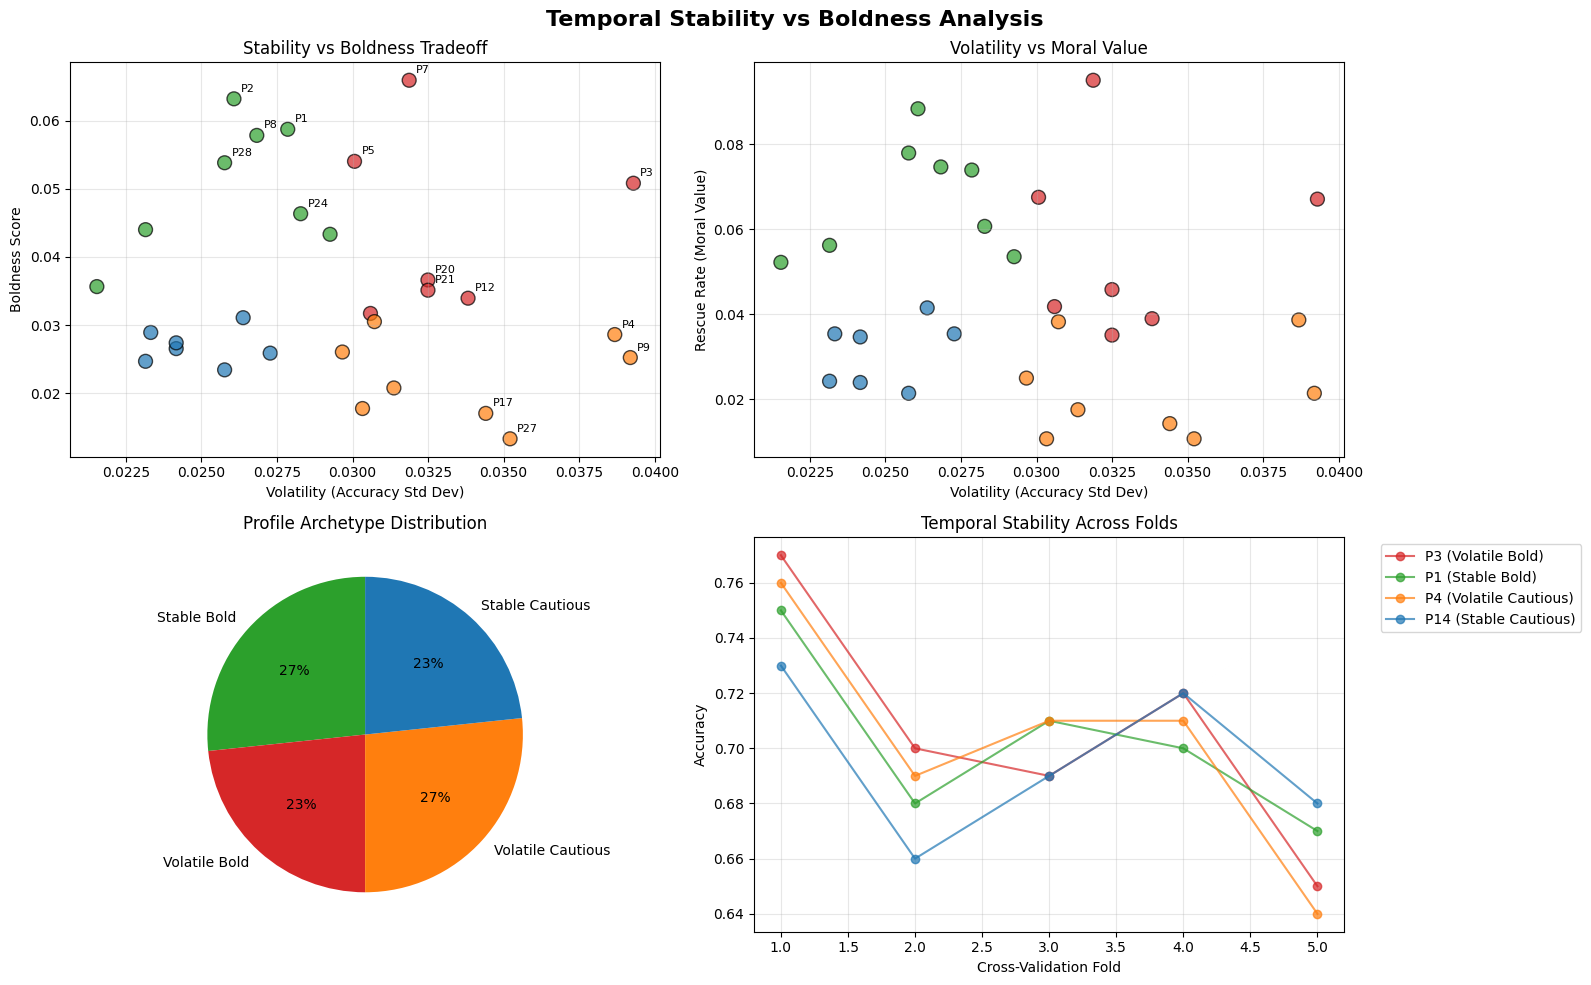


 === Creating Causal Model Visualizations... ===


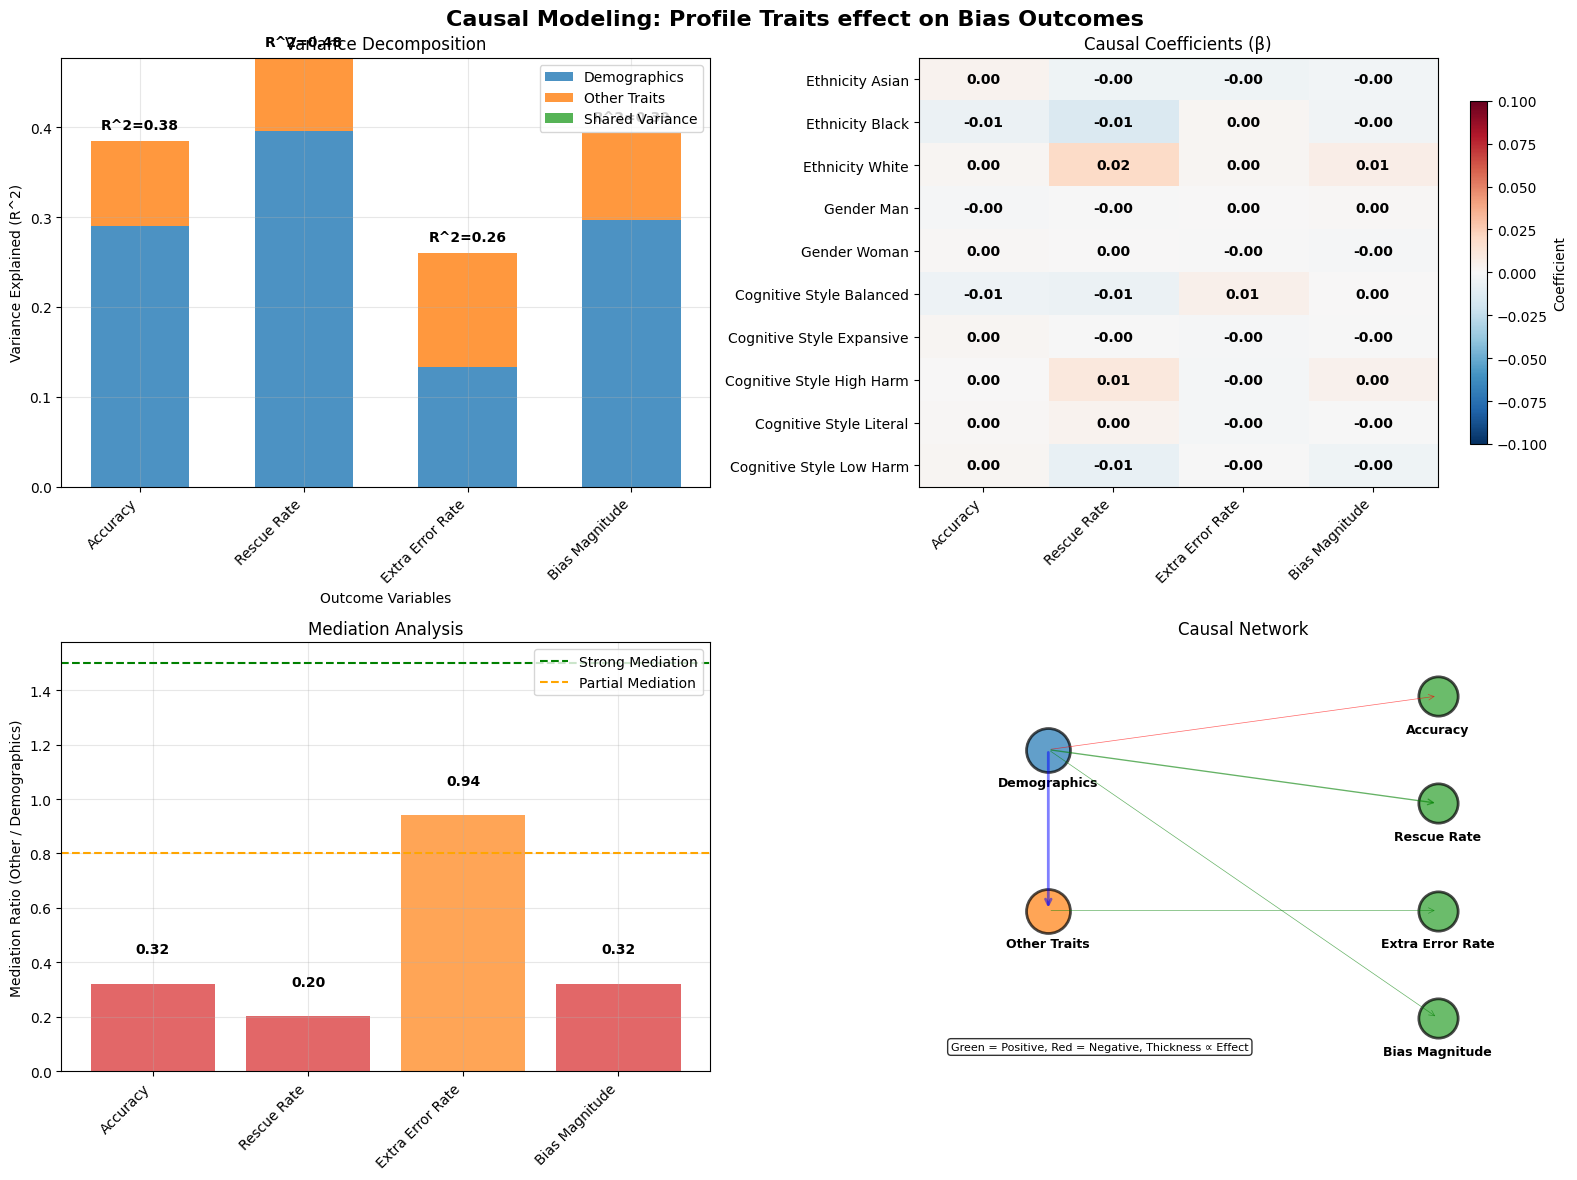


TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - --- Stable profiles outperform volatile ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Strongest predictor of moral value (rescue): ethnicity_white
   - Strongest predictor of performance (accuracy): ethnicity_black
   - Mediation effects found: extra_error_rate: Partial mediation

THESIS-LEVEL CONCLUSIONS

=== CONCLUSION 1: Demographics remain primary drivers of bias
   Evidence: Demographic factors dominate in 4/4 outcomes
   Implication: Diverse demographic representation is crucial for bias mitigation

=== CONCLUSION 2: ethnicity_white is the most critical trait for system design
   Evidence: Appears in 2/3 optimization objectives
   Implication: Systems should prioritize profiles with ethnicity_white characteristics


In [22]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

## Analysis of Few-shots role playing

In [39]:
from analysis_tools import (
    load_and_merge_profiles
    )
merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    #role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_system/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_ethnics/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'original_dataset', 'profile1_passive', 'profile2_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'profile10_passive', 'profile11_passive', 'profile12_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile20_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile25_passive', 'profile26_passive', 'profile27_passive', 'profile28_passive', 'profile29_passive', 'profile30_passive', 'profile31_passive', 'profile32_passive', 'profile33_passive', 'profile34_passive', 'profile35_passive', 'profile36_passive', 'profile37_passive', 'profile38_passive', 'profile39_passive', 'profile40_passive', 'profile41_p



=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 6
Statistical Significance Rate: 18.8%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_indian                     Effect Size: -3.180 (Large)
 2. indian_vs_latine                    Effect Size:  2.567 (Large)
 3. indian_vs_white                     Effect Size:  1.903 (Large)
 4. asian_vs_indian                     Effect Size: -1.859 (Large)
 5. black_vs_middle_eastern             Effect Size: -1.395 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.716 | Woman: 0.714
         Δ = +0.003 | p = 0.161 | d = 0.373
[SIGNIFICANT] asian_vs_black                      | Asian: 0.715 | Black: 0.709
         Δ = +0.005 | p = 0.022 | d = 1.181
[SIGNIFI

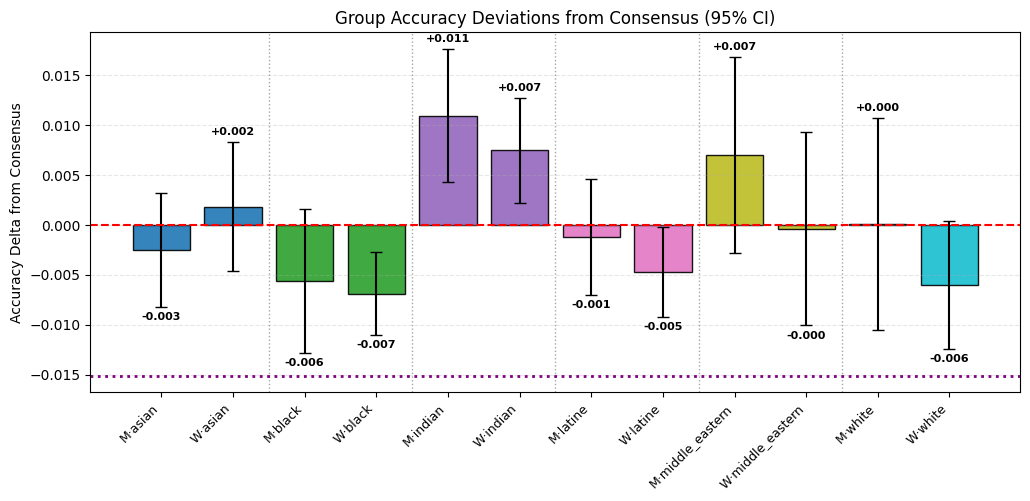

In [40]:
from analysis_0 import *

results = run_full_preliminary_analysis(merged_df, df = sample_mgsd, person_set=PERSON_ETHNICS)
#results = run_full_preliminary_analysis(merged_df, df = sample_mgsd, person_set=PERSON_SYSTEMATIC)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.700000 - 0.732000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.716467  0.007873
woman      30  0.713800  0.006630

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.7148  0.005095
black              10  0.7094  0.004526
indian             10  0.7236  0.004881
latine             10  0.7124  0.004300
middle_eastern     10  0.7182  0.008244
white              10  0.7124  0.007291

AGE:
     count      mean       std
age   

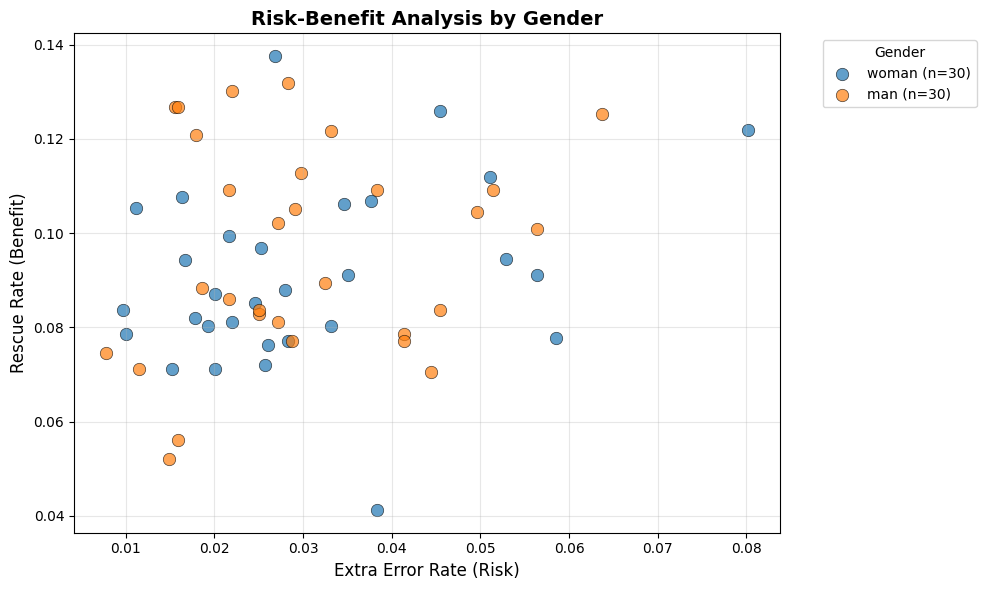


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


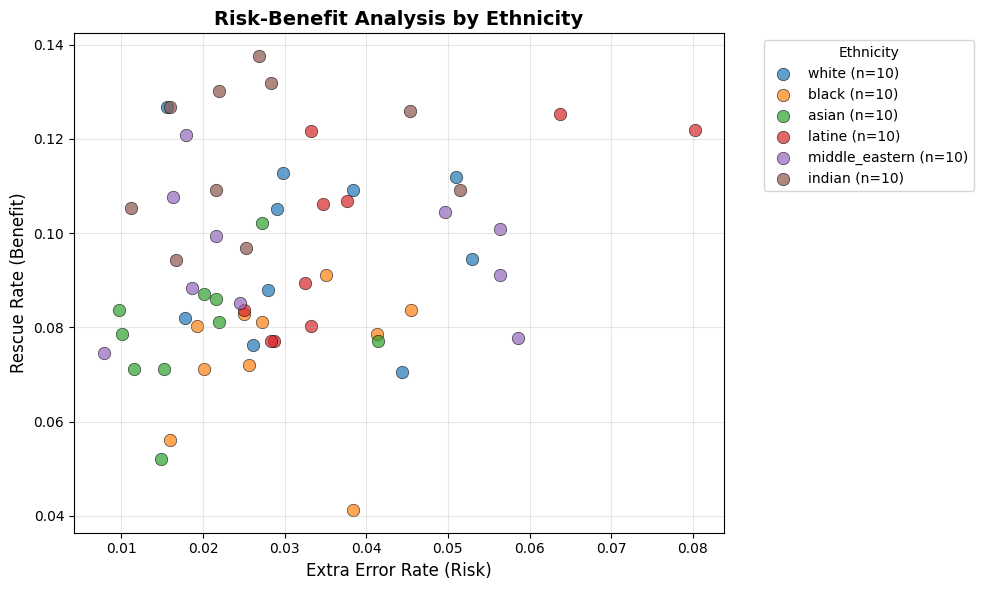


Creating risk-benefit plot for age...
  age levels: ['55', '20', '25', '35', '45']


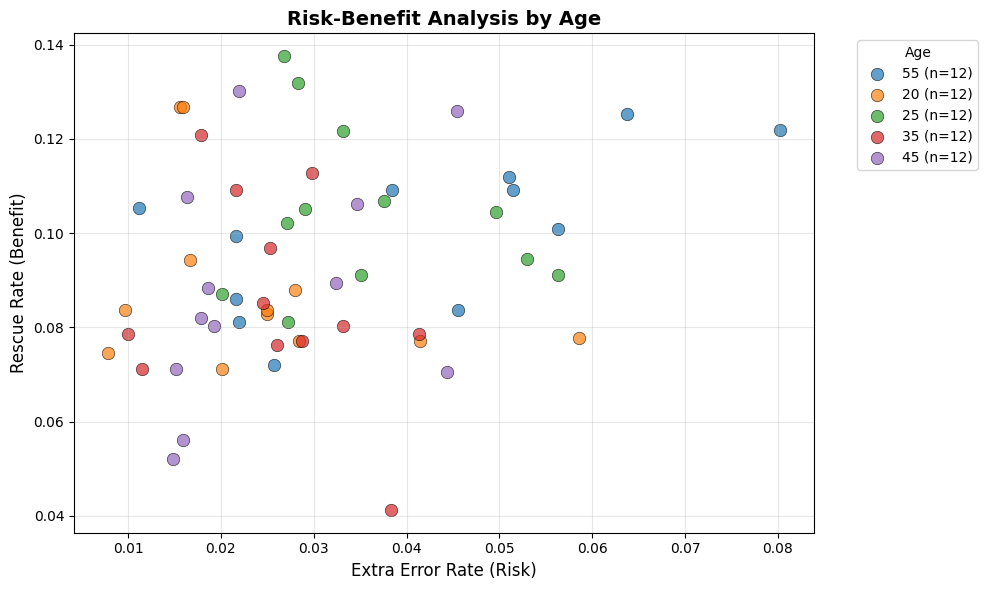


Creating Pareto frontier analysis...


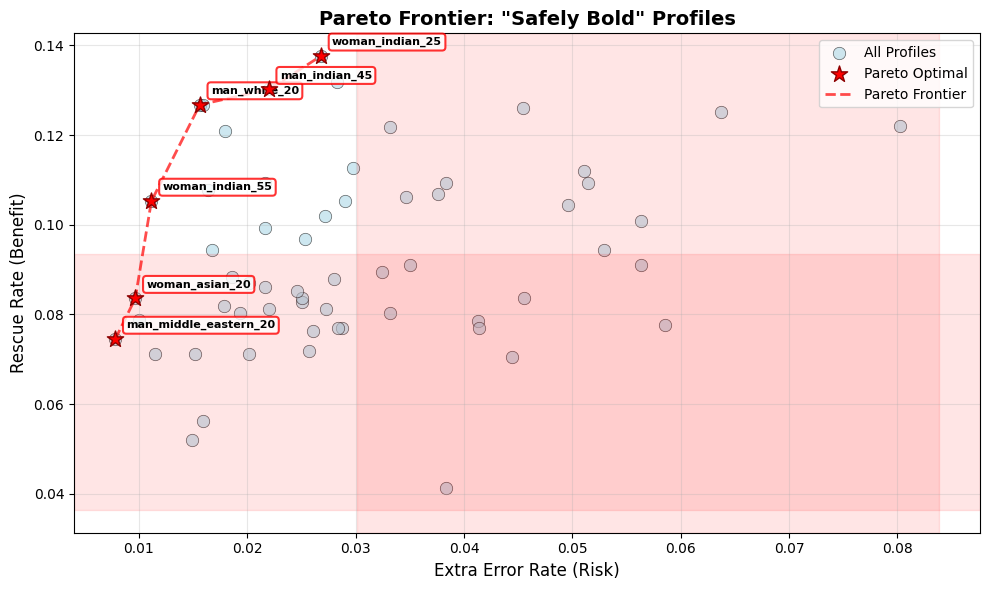


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (6 found):
  man_white_20 (profile1_passive)
    Rescue Rate: 0.127, Extra Error Rate: 0.016
    Total Rescued: 25, Total Extra Errors: 10
  woman_asian_20 (profile26_passive)
    Rescue Rate: 0.084, Extra Error Rate: 0.010
    Total Rescued: 18, Total Extra Errors: 6
  man_middle_eastern_20 (profile41_passive)
    Rescue Rate: 0.074, Extra Error Rate: 0.008
    Total Rescued: 16, Total Extra Errors: 5
  man_indian_45 (profile54_passive)
    Rescue Rate: 0.130, Extra Error Rate: 0.022
    Total Rescued: 24, Total Extra Errors: 10
  woman_indian_25 (profile57_passive)
    Rescue Rate: 0.138, Extra Error Rate: 0.027
    Total Rescued: 26, Total Extra Errors: 13
  woman_indian_55 (profile60_passive)
    Rescue Rate: 0.105, Extra Error Rate: 0.011
    Total Rescued: 20, Total Extra Errors: 7

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.094
  Average extra error rate: 0.030
  Best rescue rate: 0.1

In [41]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, group_keys=("gender", "ethnicity", "age"), person_set=PERSON_ETHNICS)
#result_tier1 = run_full_tier1_analysis(merged_df, group_keys=("gender", "ethnicity", "cognitive_style"), person_set=PERSON_SYSTEMATIC)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 65)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
  DEBUG: profile1 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile2 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile3 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile4 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile5 -> {'gender': 'man', 'ethnicity': 'white'}
  DEBUG: profile6 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile7 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile8 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile9 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile10 -> {'gender': 'woman', 'ethnicity': 'white'}
  DEBUG: profile11 -> {'gender': 'man', 'ethnicity': 

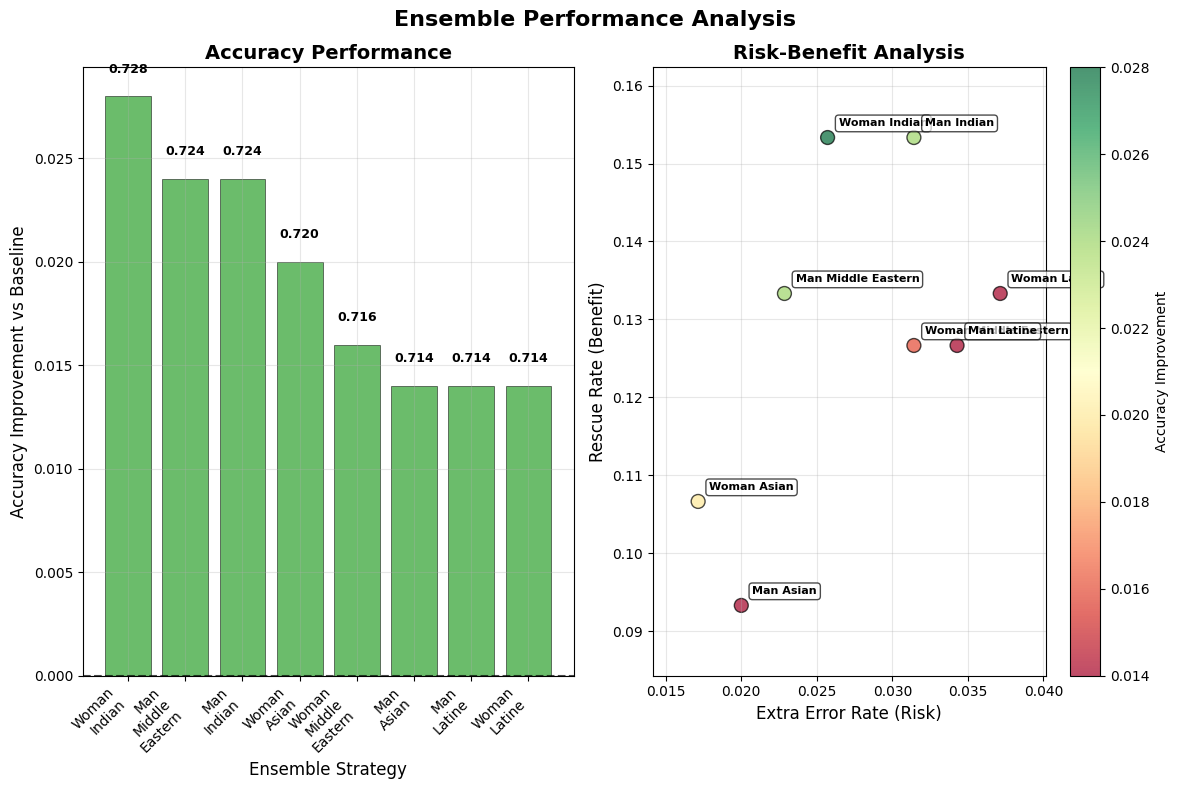

2. Cluster Analysis...


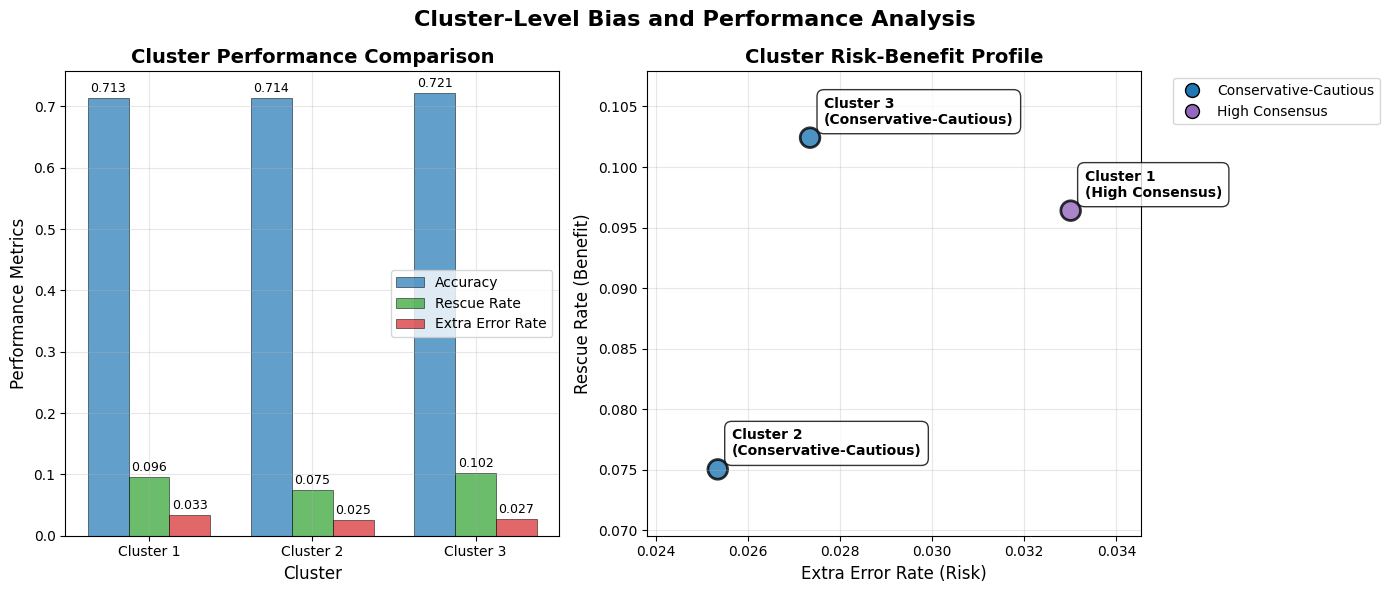

3. Trait Comparison Analysis...


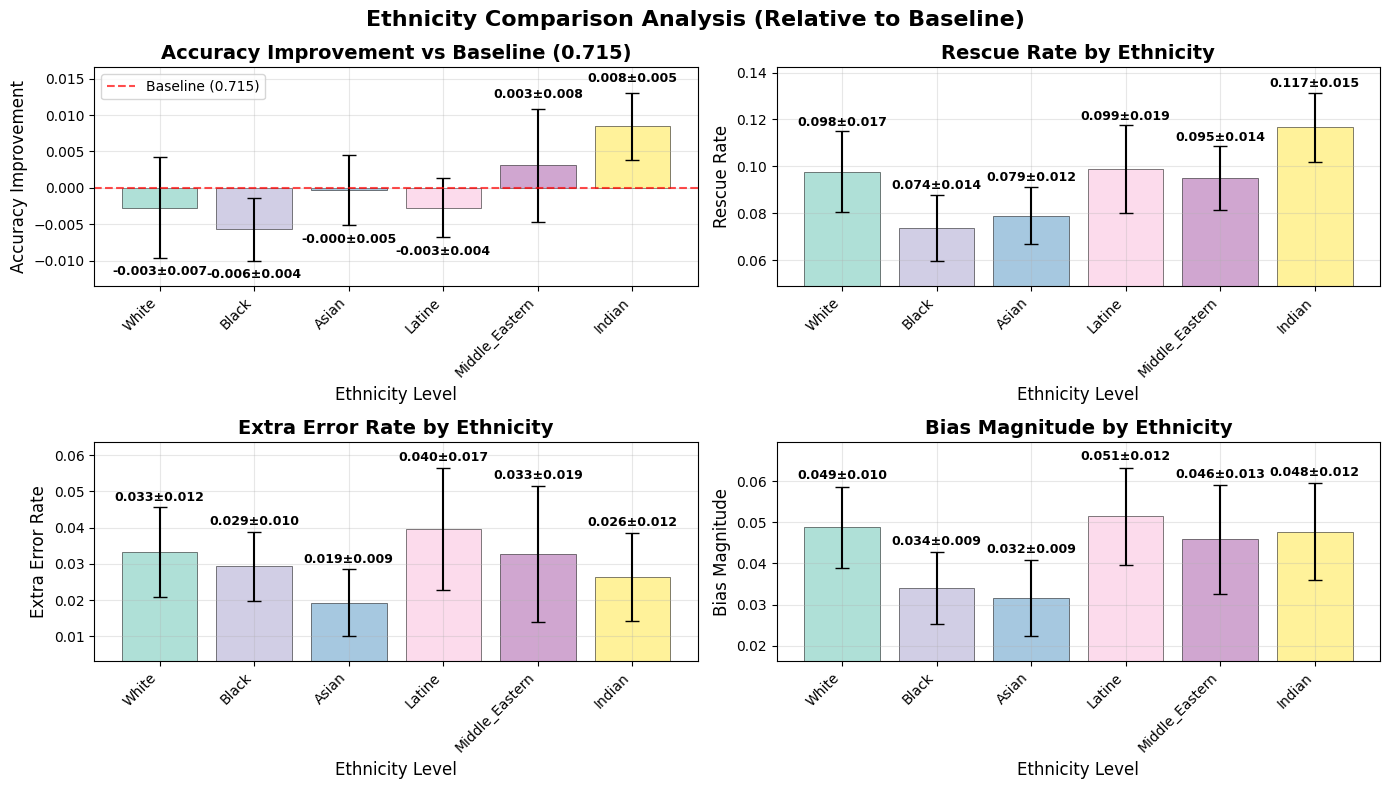

4. System-Level Recommendations...


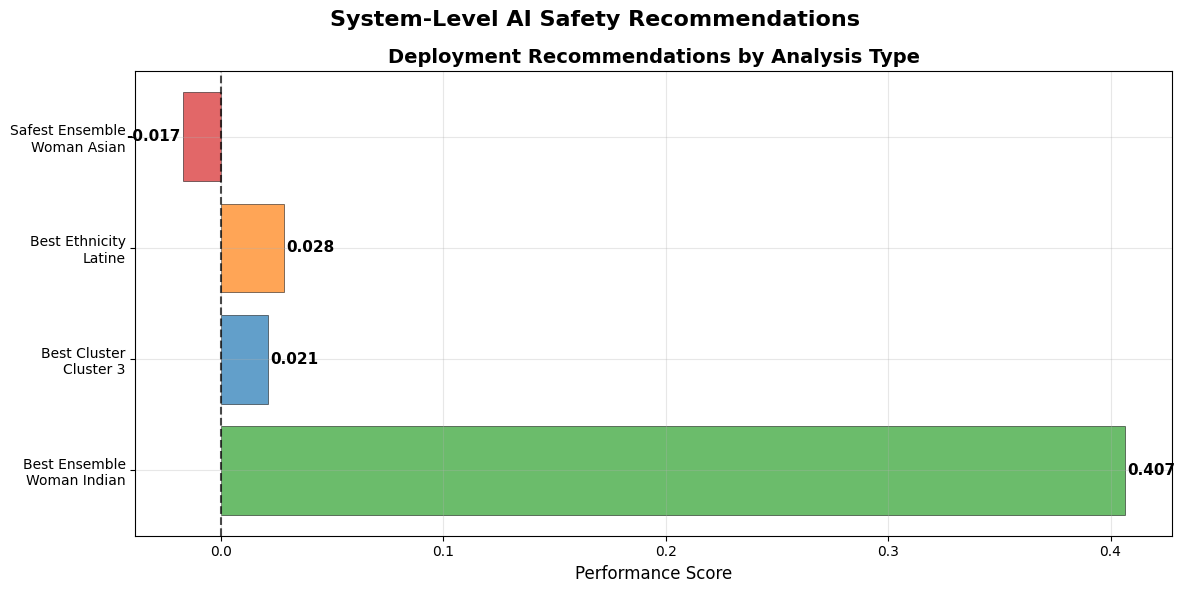


Completed! Created 4 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY

=== ENSEMBLE FINDINGS:
   • Best Overall Strategy: woman_indian
   • Safest Strategy: woman_asian
   • Best Rescue Strategy: man_indian
   • Performance Improvement: +0.0280
   • Minimum Extra Error Rate: 0.017

=== CLUSTER FINDINGS:
   • Best Performing Cluster: cluster_3
   • Safest Cluster: cluster_2
   • Cluster Ensemble Improvement: +0.0280

=== TRAIT COMPARISON FINDINGS:
   • Successful analyses: 3
   • Best age: 55 (score: 0.190)
   • Best gender: man (score: 0.200)
   • Best ethnicity: latine (score: 0.283)

=== STATISTICAL SIGNIFICANCE:
   • 6 significant effects detected
   • age → extra_error_rates: p=0.0271
   • age → bias_magnitudes: p=0.0031
   • ethnicity → accuracies: p=0.0003
   • ethnicity → rescue_rates: p=0.0001
   • ethnicity → extra_error_rates: p=0.0254

=== FINAL RECOMMENDATIONS:
   DEPLOY: woman_indian ensemble
      Expected improvement: 

In [42]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

#result_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_ETHNICS)
tier2_results = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"),
    trait_analyses=[
        ("cognitive_style", ["gender", "ethnicity"]),
        ("age", ["gender", "ethnicity"]),
        ("gender", ["ethnicity"]),
        ("ethnicity", [])
    ],
    create_visualizations=True,
    debug_mode=False,
)

#results_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

🚀 EXECUTING TIER 3 ANALYSIS PIPELINE

 === Running Temporal Stability vs Boldness Analysis... === 
TEMPORAL STABILITY vs BOLDNESS TRADEOFF ANALYSIS
=== Calculating temporal stability across 5 folds...
=== Calculating boldness metrics...
=== Analyzing stability-boldness correlations...

--- CORRELATION RESULTS:
  Volatility vs Boldness: r=0.174, p=0.3591 
  Volatility vs Rescue Rate: r=0.059, p=0.7553 
  Boldness vs Accuracy: r=0.231, p=0.2191 

=== PROFILE CLASSIFICATION:
  profile1 (gender=man, ethnicity=white, cognitive_style=expansive): Volatile Bold – High risk, high moral value
  profile2 (gender=man, ethnicity=white, cognitive_style=literal): Volatile Bold – High risk, high moral value
  profile3 (gender=man, ethnicity=white, cognitive_style=high_harm): Volatile Bold – High risk, high moral value
  profile4 (gender=man, ethnicity=white, cognitive_style=low_harm): Stable Cautious – Low risk, predictable
  profile5 (gender=man, ethnicity=white, cognitive_style=balanced): Volatile B

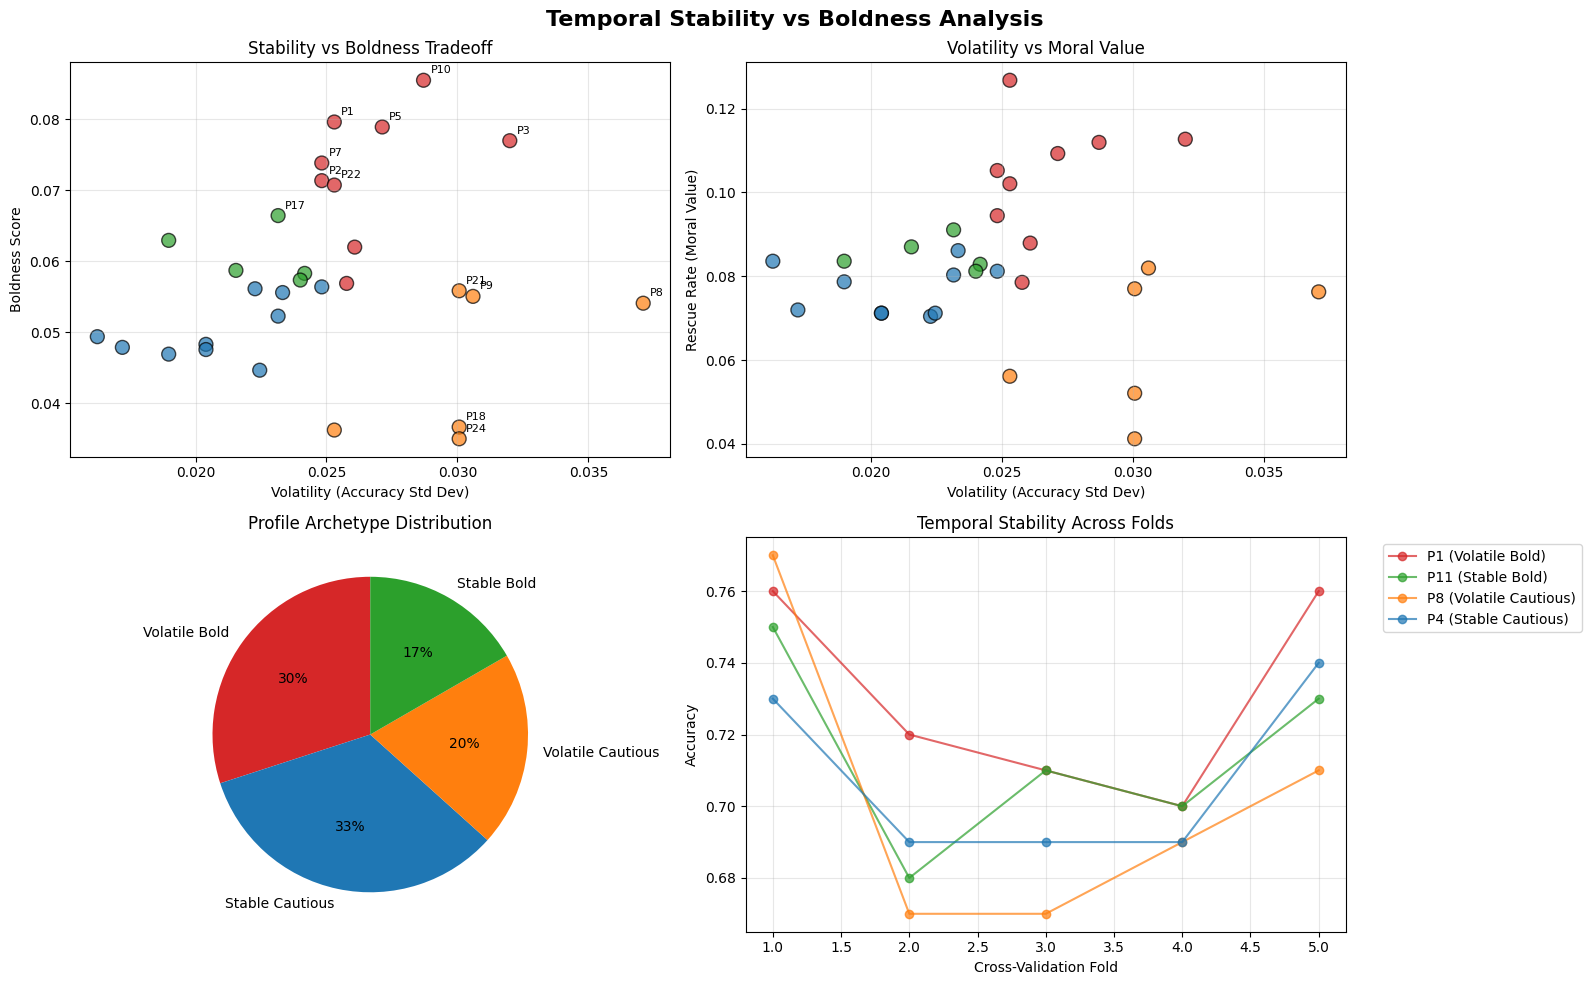


 === Creating Causal Model Visualizations... ===


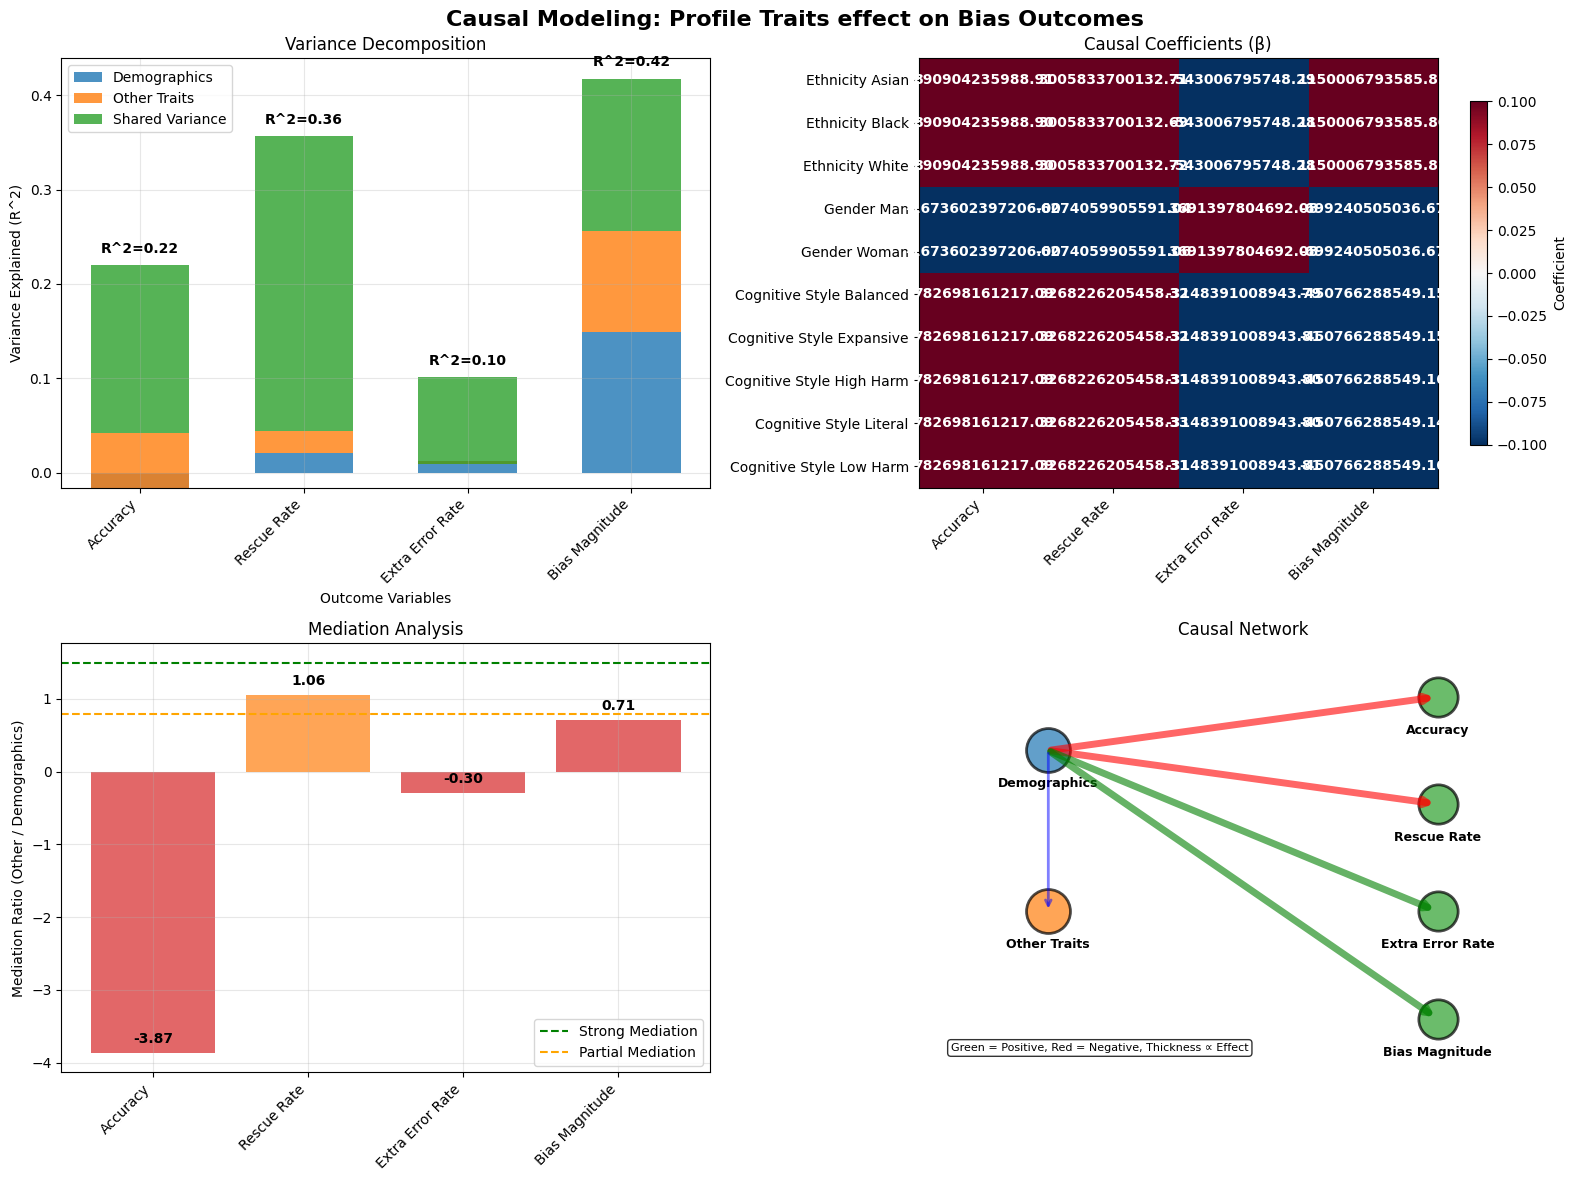


TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - --- Volatile profiles provide higher moral value through increased rescue rates
   - Implication: Risk-taking in AI annotation may be normatively justified
   - Strongest predictor of moral value (rescue): gender_woman
   - Strongest predictor of performance (accuracy): gender_woman
   - Mediation effects found: rescue_rate: Partial mediation

THESIS-LEVEL CONCLUSIONS

=== CONCLUSION 1: Demographics remain primary drivers of bias
   Evidence: Demographic factors dominate in 2/4 outcomes
   Implication: Diverse demographic representation is crucial for bias mitigation

=== CONCLUSION 2: cognitive_style_expansive is the most critical trait for system design
   Evidence: Appears in 2/3 optimization objectives
   Implication: Systems should prioritize profiles with cognitive_style_expansive characteristics


In [9]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

## Manipulation detection